In [5]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
df = pd.read_csv("D:/Downloads/continuous_dataset.csv")

df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [6]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
df = df.set_index("datetime")

In [7]:
print("Inferred frequency:", pd.infer_freq(df.index))

df = df.asfreq("h")

print(df.isna().sum().sum(), "missing values after asfreq")
df.head()

Inferred frequency: h
0 missing values after asfreq


,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


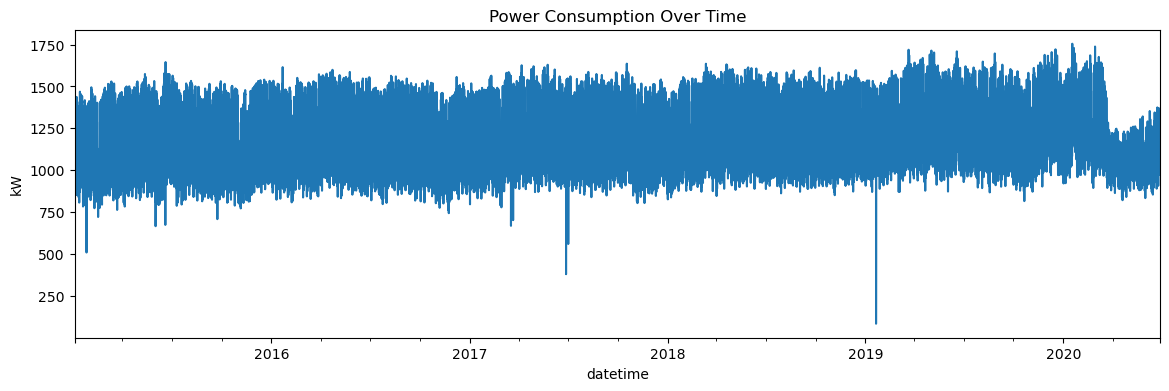

In [8]:
target_col = "nat_demand"

fig, ax = plt.subplots(figsize=(14, 4))
df[target_col].plot(ax=ax)
ax.set_title("Power Consumption Over Time")
ax.set_ylabel("kW")
plt.show()

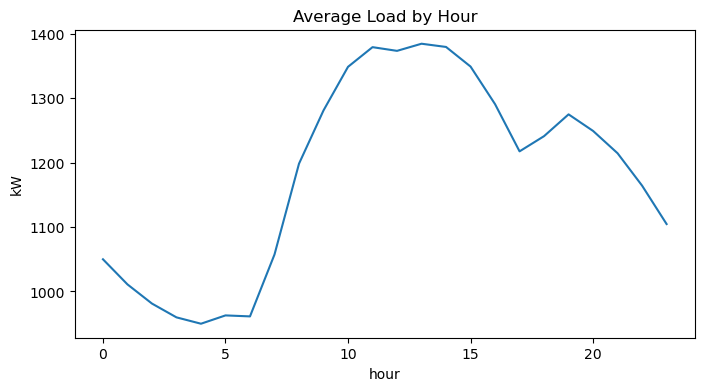

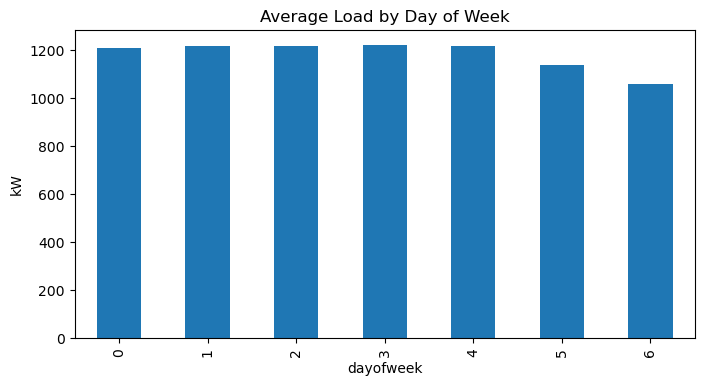

In [9]:
tmp = df.copy()
tmp["hour"] = tmp.index.hour
tmp["dayofweek"] = tmp.index.dayofweek

hourly_profile = tmp.groupby("hour")[target_col].mean()
daily_profile = tmp.groupby("dayofweek")[target_col].mean()

fig, ax = plt.subplots(figsize=(8, 4))
hourly_profile.plot(ax=ax)
ax.set_title("Average Load by Hour")
ax.set_ylabel("kW")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
daily_profile.plot(kind="bar", ax=ax)
ax.set_title("Average Load by Day of Week")
ax.set_ylabel("kW")
plt.show()

In [10]:
df_model = df.copy()

In [11]:
def add_time_features(data):
    data = data.copy()
    
    data["hour"] = data.index.hour
    data["dayofweek"] = data.index.dayofweek
    data["month"] = data.index.month
    data["is_weekend"] = (data["dayofweek"] >= 5).astype(int)
    
    data["weekofyear"] = data.index.isocalendar().week.astype(int)
    data["is_month_start"] = data.index.is_month_start.astype(int)
    data["is_month_end"] = data.index.is_month_end.astype(int)
    
    data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
    data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)
    data["dow_sin"] = np.sin(2 * np.pi * data["dayofweek"] / 7)
    data["dow_cos"] = np.cos(2 * np.pi * data["dayofweek"] / 7)
    
    return data


def add_lag_features(data, target_col, lags):
    data = data.copy()
    for lag in lags:
        data[f"{target_col}_lag_{lag}"] = data[target_col].shift(lag)
    return data


def add_rolling_features(data, target_col, windows):
    data = data.copy()
    for w in windows:
        data[f"{target_col}_roll_mean_{w}"] = data[target_col].shift(1).rolling(w).mean()
        data[f"{target_col}_roll_std_{w}"] = data[target_col].shift(1).rolling(w).std()
        data[f"{target_col}_roll_min_{w}"] = data[target_col].shift(1).rolling(w).min()
        data[f"{target_col}_roll_max_{w}"] = data[target_col].shift(1).rolling(w).max()
    return data

In [12]:
target_col = "nat_demand"

base_lags = list(range(1, 25))
seasonal_lags = [48, 72, 168]
lags = sorted(set(base_lags + seasonal_lags))

rolling_windows = [3, 6, 12, 24, 168]

horizons = {
    "6h": 6,
    "12h": 12,
    "24h": 24
}

df_feat = df_model.copy()
df_feat = add_time_features(df_feat)
df_feat = add_lag_features(df_feat, target_col, lags)
df_feat = add_rolling_features(df_feat, target_col, rolling_windows)

df_feat.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,...,nat_demand_roll_min_12,nat_demand_roll_max_12,nat_demand_roll_mean_24,nat_demand_roll_std_24,nat_demand_roll_min_24,nat_demand_roll_max_24,nat_demand_roll_mean_168,nat_demand_roll_std_168,nat_demand_roll_min_168,nat_demand_roll_max_168
datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
horizons = {
    "6h": 6,
    "12h": 12,
    "24h": 24
}

for label, step in horizons.items():
    df_feat[f"target_{label}"] = df_feat[target_col].shift(-step)

df_feat.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,...,nat_demand_roll_std_24,nat_demand_roll_min_24,nat_demand_roll_max_24,nat_demand_roll_mean_168,nat_demand_roll_std_168,nat_demand_roll_min_168,nat_demand_roll_max_168,target_6h,target_12h,target_24h
datetime,,,,,,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,932.4876,1202.1556,944.0556
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1048.9720,1197.2616,928.7193
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1167.9074,1169.0034,909.5566
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1257.5069,1136.7054,894.6543
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1254.5830,1101.9447,884.6659


In [14]:
lag_features = [col for col in df_feat.columns if f"{target_col}_lag_" in col]

# lag + time + rolling + selected exogenous variables
time_features = [
    "hour", "dayofweek", "month", "is_weekend",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "weekofyear", "is_month_start", "is_month_end"
]

rolling_features = [col for col in df_feat.columns if "roll_" in col]

exo_features = [
    "T2M_toc", "QV2M_toc", "TQL_toc", "W2M_toc",
    "T2M_san", "QV2M_san", "TQL_san", "W2M_san",
    "T2M_dav", "QV2M_dav", "TQL_dav", "W2M_dav",
    "Holiday_ID", "holiday", "school"
]

feature_set_A = lag_features
feature_set_B = lag_features + time_features + rolling_features + exo_features

target_cols = [f"target_{k}" for k in horizons.keys()]

print("Feature set A:", len(feature_set_A))
print("Feature set B:", len(feature_set_B))
print("Targets:", target_cols)

Feature set A: 27
Feature set B: 73
Targets: ['target_6h', 'target_12h', 'target_24h']


In [15]:
model_data = df_feat.dropna().copy()

print(model_data.shape)
model_data[target_cols].head()

(47856, 77)


,target_6h,target_12h,target_24h
datetime,,,
2015-01-10 01:00:00,897.8229,1161.4116,924.2795
2015-01-10 02:00:00,1021.6720,1133.3133,887.4576
2015-01-10 03:00:00,1108.9439,1100.6097,858.9606
2015-01-10 04:00:00,1165.4756,1082.6875,847.4881
2015-01-10 05:00:00,1179.0630,1051.4135,842.7522


In [16]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred, eps=1e-6):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100


def evaluate_multihorizon(y_true, y_pred, target_names):
    rows = []
    for i, name in enumerate(target_names):
        yt = y_true[:, i]
        yp = y_pred[:, i]
        rows.append({
            "horizon": name,
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": rmse(yt, yp),
            "MAPE": mape(yt, yp)
        })
    return pd.DataFrame(rows)

In [17]:
def rolling_origin_splits(n_obs, train_size, test_size, step_size):
    """
    Expanding-window splits:
    Train: [0 : train_end]
    Test:  [train_end : train_end + test_size]
    """
    splits = []
    train_end = train_size
    
    while train_end + test_size <= n_obs:
        train_idx = np.arange(0, train_end)
        test_idx = np.arange(train_end, train_end + test_size)
        splits.append((train_idx, test_idx))
        train_end += step_size
    
    return splits

In [18]:
n_obs = len(model_data)

train_size = 30000
test_size = 4000
step_size = 4000

splits = rolling_origin_splits(
    n_obs=n_obs,
    train_size=train_size,
    test_size=test_size,
    step_size=step_size
)

print("Number of CV splits:", len(splits))
for i, (tr, te) in enumerate(splits[:3], 1):
    print(f"Split {i}: train={len(tr)}, test={len(te)}")

Number of CV splits: 4
Split 1: train=30000, test=4000
Split 2: train=34000, test=4000
Split 3: train=38000, test=4000


In [19]:
def run_cv_model(data, feature_cols, target_cols, model):
    X = data[feature_cols].values
    y = data[target_cols].values
    
    fold_metrics = []
    all_preds = []
    all_truth = []
    
    for fold, (train_idx, test_idx) in enumerate(splits, 1):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        fold_result = evaluate_multihorizon(y_test, y_pred, target_cols)
        fold_result["fold"] = fold
        fold_metrics.append(fold_result)
        
        pred_df = pd.DataFrame(y_pred, columns=[f"pred_{c}" for c in target_cols], index=data.index[test_idx])
        true_df = pd.DataFrame(y_test, columns=[f"true_{c}" for c in target_cols], index=data.index[test_idx])
        merged = pd.concat([true_df, pred_df], axis=1)
        merged["fold"] = fold
        
        all_preds.append(merged)
        all_truth.append((y_test, y_pred))
    
    metrics_df = pd.concat(fold_metrics, ignore_index=True)
    preds_df = pd.concat(all_preds, axis=0)
    
    return metrics_df, preds_df

In [20]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

lin_A_metrics, lin_A_preds = run_cv_model(
    data=model_data,
    feature_cols=feature_set_A,
    target_cols=target_cols,
    model=linear_model
)

lin_A_metrics.groupby("horizon")[["MAE", "RMSE", "MAPE"]].mean().round(4)

,MAE,RMSE,MAPE
horizon,,,
target_12h,81.3141,112.6155,6.5170
target_24h,79.7038,108.1888,6.4562
target_6h,68.7173,100.0117,5.5811


In [21]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

ridge_results = []

for alpha in alphas:
    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])
    
    metrics_df, _ = run_cv_model(
        data=model_data,
        feature_cols=feature_set_A,
        target_cols=target_cols,
        model=ridge_model
    )
    
    avg_rmse = metrics_df["RMSE"].mean()
    ridge_results.append({"alpha": alpha, "avg_RMSE": avg_rmse})

ridge_tuning = pd.DataFrame(ridge_results).sort_values("avg_RMSE")
ridge_tuning

,alpha,avg_RMSE
2,1.00,106.938578
1,0.10,106.938633
0,0.01,106.938640
3,10.00,106.939378
4,100.00,107.009935


In [22]:
best_alpha = ridge_tuning.iloc[0]["alpha"]
best_alpha

np.float64(1.0)

In [23]:
ridge_A_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_alpha))
])

ridge_A_metrics, ridge_A_preds = run_cv_model(
    data=model_data,
    feature_cols=feature_set_A,
    target_cols=target_cols,
    model=ridge_A_model
)

ridge_A_summary = ridge_A_metrics.groupby("horizon")[["MAE", "RMSE", "MAPE"]].mean().round(4)
ridge_A_summary

,MAE,RMSE,MAPE
horizon,,,
target_12h,81.3141,112.6152,6.5170
target_24h,79.7049,108.1883,6.4563
target_6h,68.7153,100.0122,5.5809


In [24]:
ridge_B_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_alpha))
])

ridge_B_metrics, ridge_B_preds = run_cv_model(
    data=model_data,
    feature_cols=feature_set_B,
    target_cols=target_cols,
    model=ridge_B_model
)

ridge_B_summary = ridge_B_metrics.groupby("horizon")[["MAE", "RMSE", "MAPE"]].mean().round(4)
ridge_B_summary

,MAE,RMSE,MAPE
horizon,,,
target_12h,62.7906,86.2486,5.3176
target_24h,66.3872,87.8442,5.6531
target_6h,52.3782,71.1561,4.5158


In [25]:
def add_model_name(summary_df, model_name):
    out = summary_df.copy().reset_index()
    out["model"] = model_name
    return out

comparison = pd.concat([
    add_model_name(lin_A_metrics.groupby("horizon")[["MAE", "RMSE", "MAPE"]].mean().round(4), "Linear_A_lag_only"),
    add_model_name(ridge_A_summary, "Ridge_A_lag_only"),
    add_model_name(ridge_B_summary, "Ridge_B_full_features")
], ignore_index=True)

comparison = comparison[["model", "horizon", "MAE", "RMSE", "MAPE"]]
comparison

,model,horizon,MAE,RMSE,MAPE
0,Linear_A_lag_only,target_12h,81.3141,112.6155,6.5170
1,Linear_A_lag_only,target_24h,79.7038,108.1888,6.4562
2,Linear_A_lag_only,target_6h,68.7173,100.0117,5.5811
3,Ridge_A_lag_only,target_12h,81.3141,112.6152,6.5170
4,Ridge_A_lag_only,target_24h,79.7049,108.1883,6.4563
5,Ridge_A_lag_only,target_6h,68.7153,100.0122,5.5809
6,Ridge_B_full_features,target_12h,62.7906,86.2486,5.3176
7,Ridge_B_full_features,target_24h,66.3872,87.8442,5.6531
8,Ridge_B_full_features,target_6h,52.3782,71.1561,4.5158


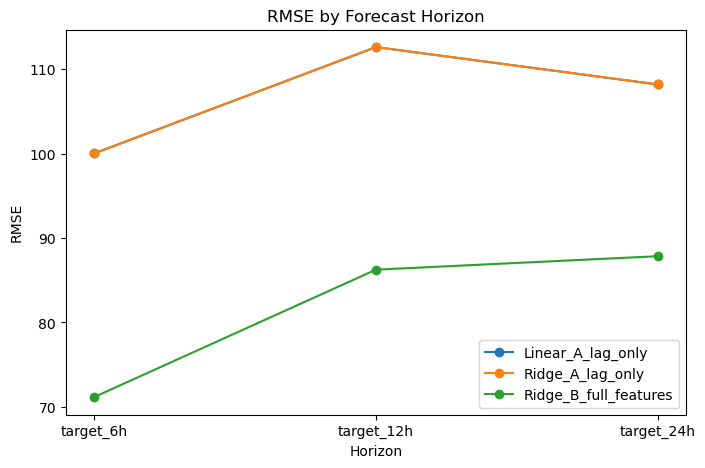

In [40]:
plot_df = comparison.copy()
plot_df["horizon_order"] = plot_df["horizon"].map({
    "target_6h": 1,
    "target_12h": 2,
    "target_24h": 3
})
plot_df = plot_df.sort_values(["model", "horizon_order"])

fig, ax = plt.subplots(figsize=(8, 5))
for model_name, grp in plot_df.groupby("model"):
    ax.plot(grp["horizon"], grp["RMSE"], marker="o", label=model_name)

ax.set_title("RMSE by Forecast Horizon")
ax.set_xlabel("Horizon")
ax.set_ylabel("RMSE")
ax.legend()
plt.show()

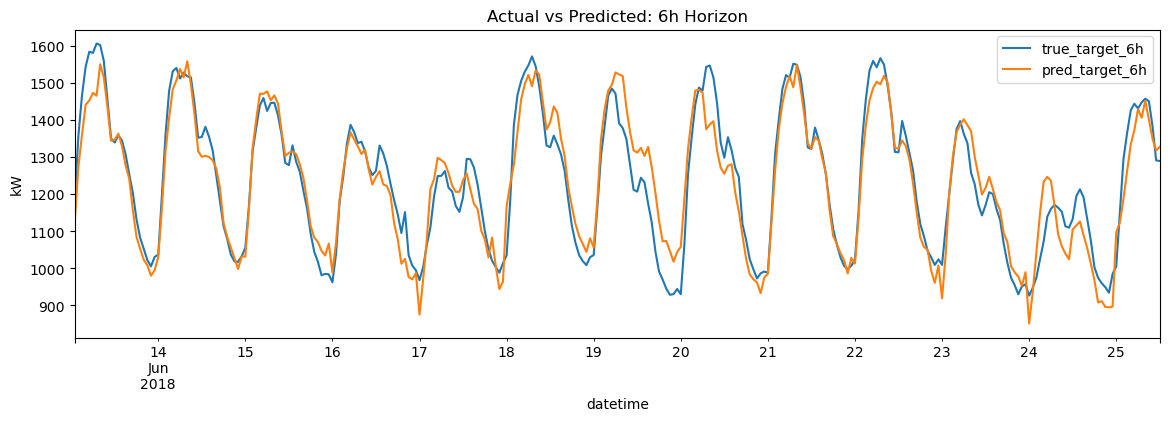

In [28]:
example = ridge_B_preds.copy()

col_true = "true_target_6h"
col_pred = "pred_target_6h"

fig, ax = plt.subplots(figsize=(14, 4))
example[[col_true, col_pred]].iloc[:300].plot(ax=ax)
ax.set_title("Actual vs Predicted: 6h Horizon")
ax.set_ylabel("kW")
plt.show()

In [29]:
# Fit on full dataset for interpretation only
X_full = model_data[feature_set_B].values
y_full = model_data[target_cols].values

ridge_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=best_alpha))
])

ridge_final.fit(X_full, y_full)

coefs = ridge_final.named_steps["model"].coef_  # shape: [n_targets, n_features]

coef_df = pd.DataFrame(
    coefs.T,
    index=feature_set_B,
    columns=target_cols
)

coef_df.head()

,target_6h,target_12h,target_24h
nat_demand_lag_1,36.448683,39.160330,130.522191
nat_demand_lag_2,-58.312865,10.014253,-54.090071
nat_demand_lag_3,-53.332142,-12.425101,-22.070600
nat_demand_lag_4,-15.289734,-13.126286,-17.958309
nat_demand_lag_5,23.104737,4.832154,20.736045


In [30]:
# Top absolute coefficients for 6h horizon
top_features_6h = coef_df["target_6h"].abs().sort_values(ascending=False).head(20)
top_features_6h

nat_demand_roll_min_3      331.954517
nat_demand_roll_max_3      230.700473
nat_demand_lag_18          108.673558
nat_demand_roll_std_3      102.144754
dayofweek                   78.851597
nat_demand_lag_2            58.312865
nat_demand_lag_3            53.332142
nat_demand_roll_std_24      46.505652
hour_cos                    45.486115
dow_cos                     43.604761
nat_demand_lag_1            36.448683
nat_demand_roll_max_6       34.427677
nat_demand_roll_max_168     34.209529
nat_demand_lag_168          33.915929
nat_demand_roll_min_6       33.094237
nat_demand_roll_min_24      33.088223
nat_demand_lag_17           31.783841
holiday                     31.591564
hour_sin                    29.425955
nat_demand_lag_23           28.525851
Name: target_6h, dtype: float64

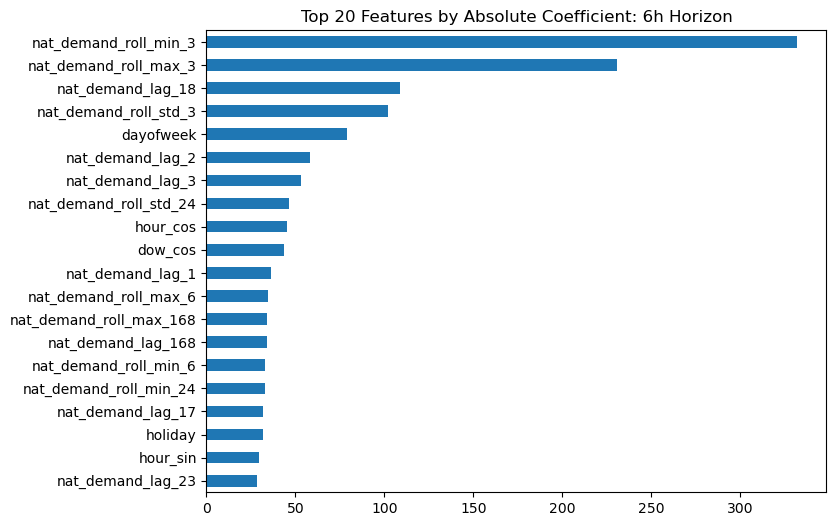

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
top_features_6h.sort_values().plot(kind="barh", ax=ax)
ax.set_title("Top 20 Features by Absolute Coefficient: 6h Horizon")
plt.show()

In [33]:
def naive_forecast(data, target_col, horizon_steps, test_idx):
    y_true = data[target_col].shift(-horizon_steps).iloc[test_idx]
    y_pred = data[target_col].shift(0).iloc[test_idx]
    return y_true.values, y_pred.values

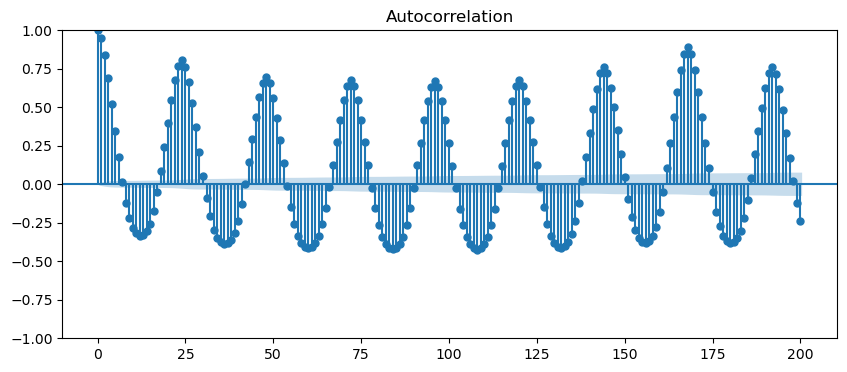

In [34]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10,4))
plot_acf(df[target_col], lags=200, ax=ax)
plt.show()

In [43]:
comparison["horizon"] = pd.Categorical(
    comparison["horizon"],
    categories=["target_6h", "target_12h", "target_24h"],
    ordered=True
)

comparison = comparison.sort_values(["model", "horizon"])

comparison_pivot = comparison.pivot(index="horizon", columns="model", values="RMSE")
comparison_pivot.index = comparison_pivot.index.str.replace("target_", "")
comparison_pivot

model,Linear_A_lag_only,Ridge_A_lag_only,Ridge_B_full_features
horizon,,,
6h,100.0117,100.0122,71.1561
12h,112.6155,112.6152,86.2486
24h,108.1888,108.1883,87.8442


In [ ]:
#Forecast error increases significantly from 6 to 12 hours ahead, but shows limited additional degradation between 12 and 24 hours, 
#suggesting that demand becomes less dependent on recent observations and more driven by stable seasonal patterns.